In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA

In [4]:
#Đọc file csv
file_path = "/content/drive/MyDrive/KhaiPhaDuLieu/instagram_usage_lifestyle.csv"
df = pd.read_csv(file_path)
print("Danh sách cột:")
for col in df.columns:
    print(col)
print("Tổng số cột:", len(df.columns))
df.info()

Danh sách cột:
user_id
app_name
age
gender
country
urban_rural
income_level
employment_status
education_level
relationship_status
has_children
exercise_hours_per_week
sleep_hours_per_night
diet_quality
smoking
alcohol_frequency
perceived_stress_score
self_reported_happiness
body_mass_index
blood_pressure_systolic
blood_pressure_diastolic
daily_steps_count
weekly_work_hours
hobbies_count
social_events_per_month
books_read_per_year
volunteer_hours_per_month
travel_frequency_per_year
daily_active_minutes_instagram
sessions_per_day
posts_created_per_week
reels_watched_per_day
stories_viewed_per_day
likes_given_per_day
comments_written_per_day
dms_sent_per_week
dms_received_per_week
ads_viewed_per_day
ads_clicked_per_day
time_on_feed_per_day
time_on_explore_per_day
time_on_messages_per_day
time_on_reels_per_day
followers_count
following_count
uses_premium_features
notification_response_rate
account_creation_year
last_login_date
average_session_length_minutes
content_type_preference
preferre

In [5]:


#Chọn các cột hữu ích
selected_columns = [
    "user_id",
    "daily_active_minutes_instagram",
    "sessions_per_day",
    "posts_created_per_week",
    "reels_watched_per_day",
    "likes_given_per_day",
    "comments_written_per_day",
    "dms_sent_per_week",
    "dms_received_per_week",
    "ads_viewed_per_day",
    "ads_clicked_per_day",
    "time_on_feed_per_day",
    "time_on_explore_per_day",
    "time_on_messages_per_day",
    "time_on_reels_per_day",
    "followers_count",
    "following_count",
    "uses_premium_features",
    "notification_response_rate",
    "account_creation_year",
    "last_login_date",
    "average_session_length_minutes",
    "two_factor_auth_enabled",
    "biometric_login_used",
    "linked_accounts_count",
]

#lọc lại dataset và lưu vào file
df_filtered = df[selected_columns]
print("==========================")
print("Sau khi thực hiện lọc")
print("Số cột còn lại:", len(df_filtered.columns))

#output_path = "/content/drive/MyDrive/KhaiPhaDuLieu/filtered_dataset.csv"
#df_filtered.to_csv(output_path, index=False)

Sau khi thực hiện lọc
Số cột còn lại: 25


In [12]:
df_filtered=pd.read_csv("/content/drive/MyDrive/KhaiPhaDuLieu/filtered_dataset.csv")

In [13]:
#Làm sạch dữ liệu
df_filtered.columns = df_filtered.columns.str.strip() #Xóa khoảng trắng
df_filtered = df_filtered.drop_duplicates() #Xóa dòng bị trùng
df_filtered = df_filtered.fillna(df_filtered.median(numeric_only=True)) #Xóa các dòng bị rỗng dữ liệu
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 25 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   daily_active_minutes_instagram  1547896 non-null  float64
 2   sessions_per_day                1547896 non-null  int64  
 3   posts_created_per_week          1547896 non-null  int64  
 4   reels_watched_per_day           1547896 non-null  int64  
 5   likes_given_per_day             1547896 non-null  int64  
 6   comments_written_per_day        1547896 non-null  int64  
 7   dms_sent_per_week               1547896 non-null  int64  
 8   dms_received_per_week           1547896 non-null  int64  
 9   ads_viewed_per_day              1547896 non-null  int64  
 10  ads_clicked_per_day             1547896 non-null  int64  
 11  time_on_feed_per_day            1547896 non-null  int64  
 12  

In [14]:
#Chuyển đổi kiểu dữ liệu từ các object sang dữ liệu số
df_filtered['uses_premium_features'] = df_filtered['uses_premium_features'].map({'Yes': 1, 'No': 0})
df_filtered['two_factor_auth_enabled'] = df_filtered['two_factor_auth_enabled'].map({'Yes': 1, 'No': 0})
df_filtered['biometric_login_used'] = df_filtered['biometric_login_used'].map({'Yes': 1, 'No': 0})
df_filtered['last_login_date'] = pd.to_datetime(df_filtered['last_login_date'])
df_filtered['days_since_last_login'] = (pd.Timestamp.now() - df_filtered['last_login_date']).dt.days
df_filtered = df_filtered.drop(columns=['last_login_date'])

In [15]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 25 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   daily_active_minutes_instagram  1547896 non-null  float64
 2   sessions_per_day                1547896 non-null  int64  
 3   posts_created_per_week          1547896 non-null  int64  
 4   reels_watched_per_day           1547896 non-null  int64  
 5   likes_given_per_day             1547896 non-null  int64  
 6   comments_written_per_day        1547896 non-null  int64  
 7   dms_sent_per_week               1547896 non-null  int64  
 8   dms_received_per_week           1547896 non-null  int64  
 9   ads_viewed_per_day              1547896 non-null  int64  
 10  ads_clicked_per_day             1547896 non-null  int64  
 11  time_on_feed_per_day            1547896 non-null  int64  
 12  

In [16]:
#Xử lý các dữ liệu bị phi lý
#Lọc các dòng bị âm
df_filtered = df_filtered[df_filtered['daily_active_minutes_instagram'] >=0]
df_filtered = df_filtered[df_filtered['sessions_per_day'] >=0]
df_filtered = df_filtered[df_filtered['posts_created_per_week'] >=0]
df_filtered = df_filtered[df_filtered['reels_watched_per_day'] >=0]
df_filtered = df_filtered[df_filtered['likes_given_per_day'] >=0]
df_filtered = df_filtered[df_filtered['comments_written_per_day'] >=0]
df_filtered = df_filtered[df_filtered['dms_sent_per_week'] >=0]
df_filtered = df_filtered[df_filtered['dms_received_per_week'] >=0]
df_filtered = df_filtered[df_filtered['ads_viewed_per_day'] >=0]
df_filtered = df_filtered[df_filtered['ads_clicked_per_day'] >=0]
df_filtered = df_filtered[df_filtered['time_on_feed_per_day'] >=0]
df_filtered = df_filtered[df_filtered['time_on_explore_per_day'] >=0]
df_filtered = df_filtered[df_filtered['time_on_messages_per_day'] >=0]
df_filtered = df_filtered[df_filtered['time_on_reels_per_day'] >=0]
df_filtered = df_filtered[df_filtered['followers_count'] >=0]
df_filtered = df_filtered[df_filtered['following_count'] >=0]
df_filtered = df_filtered[df_filtered['account_creation_year'] >=0]
df_filtered = df_filtered[df_filtered['linked_accounts_count'] >=0]
df_filtered = df_filtered[df_filtered['days_since_last_login'] >=0]

#Lọc các dòng có thời gian không hợp lệ
df_filtered = df_filtered[df_filtered['daily_active_minutes_instagram'] <=1440]
df_filtered = df_filtered[df_filtered['time_on_feed_per_day'] <=1440]
df_filtered = df_filtered[df_filtered['time_on_explore_per_day'] <=1440]
df_filtered = df_filtered[df_filtered['time_on_messages_per_day'] <=1440]
df_filtered = df_filtered[df_filtered['time_on_reels_per_day'] <=1440]

#Lọc các column boolean có giá trị không hợp lệ
df_filtered = df_filtered[df_filtered['uses_premium_features'].isin([0,1])]
df_filtered = df_filtered[df_filtered['two_factor_auth_enabled'].isin([0,1])]
df_filtered = df_filtered[df_filtered['biometric_login_used'].isin([0,1])]

In [18]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 25 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   daily_active_minutes_instagram  1547896 non-null  float64
 2   sessions_per_day                1547896 non-null  int64  
 3   posts_created_per_week          1547896 non-null  int64  
 4   reels_watched_per_day           1547896 non-null  int64  
 5   likes_given_per_day             1547896 non-null  int64  
 6   comments_written_per_day        1547896 non-null  int64  
 7   dms_sent_per_week               1547896 non-null  int64  
 8   dms_received_per_week           1547896 non-null  int64  
 9   ads_viewed_per_day              1547896 non-null  int64  
 10  ads_clicked_per_day             1547896 non-null  int64  
 11  time_on_feed_per_day            1547896 non-null  int64  
 12  

In [19]:
df_filtered['interact_density']=(df_filtered['likes_given_per_day']+df_filtered['comments_written_per_day'])/df_filtered['daily_active_minutes_instagram']
df_filtered['interact_per_session'] = (df_filtered['likes_given_per_day'] + df_filtered['comments_written_per_day']) / df_filtered['sessions_per_day']
df_filtered['dm_ratio'] = df_filtered['dms_sent_per_week'] / df_filtered['dms_received_per_week']
df_filtered['activity_per_session'] = df_filtered['daily_active_minutes_instagram'] / df_filtered['sessions_per_day']
df_filtered['activity_intensity'] = (df_filtered['likes_given_per_day'] + df_filtered['comments_written_per_day'] + df_filtered['reels_watched_per_day'] + df_filtered['ads_viewed_per_day']) / df_filtered['daily_active_minutes_instagram']

In [20]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 30 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   daily_active_minutes_instagram  1547896 non-null  float64
 2   sessions_per_day                1547896 non-null  int64  
 3   posts_created_per_week          1547896 non-null  int64  
 4   reels_watched_per_day           1547896 non-null  int64  
 5   likes_given_per_day             1547896 non-null  int64  
 6   comments_written_per_day        1547896 non-null  int64  
 7   dms_sent_per_week               1547896 non-null  int64  
 8   dms_received_per_week           1547896 non-null  int64  
 9   ads_viewed_per_day              1547896 non-null  int64  
 10  ads_clicked_per_day             1547896 non-null  int64  
 11  time_on_feed_per_day            1547896 non-null  int64  
 12  

In [21]:
#Lọc lại các dòng dữ liệu
df_filtered['activity_score'] = (df_filtered['daily_active_minutes_instagram'] +df_filtered['activity_intensity'] +df_filtered['sessions_per_day'])
df_filtered['activity_group'] = pd.qcut(df_filtered['activity_score'],q=3,labels=['low', 'medium', 'high'])
N = len(df_filtered)
N_target = 500000
group_counts = df_filtered['activity_group'].value_counts()
sample_sizes = (group_counts * N_target / N).astype(int)
print(sample_sizes)

activity_group
low       166668
medium    166666
high      166665
Name: count, dtype: int64


In [22]:
df_sample = pd.DataFrame()
for group in ['low', 'medium', 'high']:
    df_group = df_filtered[df_filtered['activity_group'] == group]
    n_i = sample_sizes[group]
    df_sample = pd.concat([df_sample,df_group.sample(n=n_i, random_state=42)])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

In [23]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499999 entries, 0 to 499998
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   user_id                         499999 non-null  int64   
 1   daily_active_minutes_instagram  499999 non-null  float64 
 2   sessions_per_day                499999 non-null  int64   
 3   posts_created_per_week          499999 non-null  int64   
 4   reels_watched_per_day           499999 non-null  int64   
 5   likes_given_per_day             499999 non-null  int64   
 6   comments_written_per_day        499999 non-null  int64   
 7   dms_sent_per_week               499999 non-null  int64   
 8   dms_received_per_week           499999 non-null  int64   
 9   ads_viewed_per_day              499999 non-null  int64   
 10  ads_clicked_per_day             499999 non-null  int64   
 11  time_on_feed_per_day            499999 non-null  int64   
 12  ti

In [24]:
drop_cols = [
    'user_id',
    'activity_group',
    'activity_score',
    'account_creation_year',
    'uses_premium_features',
    'two_factor_auth_enabled',
    'biometric_login_used'
]

df_scale = df_sample.drop(columns=drop_cols)

In [26]:
df_scale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499999 entries, 0 to 499998
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   daily_active_minutes_instagram  499999 non-null  float64
 1   sessions_per_day                499999 non-null  int64  
 2   posts_created_per_week          499999 non-null  int64  
 3   reels_watched_per_day           499999 non-null  int64  
 4   likes_given_per_day             499999 non-null  int64  
 5   comments_written_per_day        499999 non-null  int64  
 6   dms_sent_per_week               499999 non-null  int64  
 7   dms_received_per_week           499999 non-null  int64  
 8   ads_viewed_per_day              499999 non-null  int64  
 9   ads_clicked_per_day             499999 non-null  int64  
 10  time_on_feed_per_day            499999 non-null  int64  
 11  time_on_explore_per_day         499999 non-null  int64  
 12  time_on_messages

In [27]:
#Chuẩn hóa
X = df_scale.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

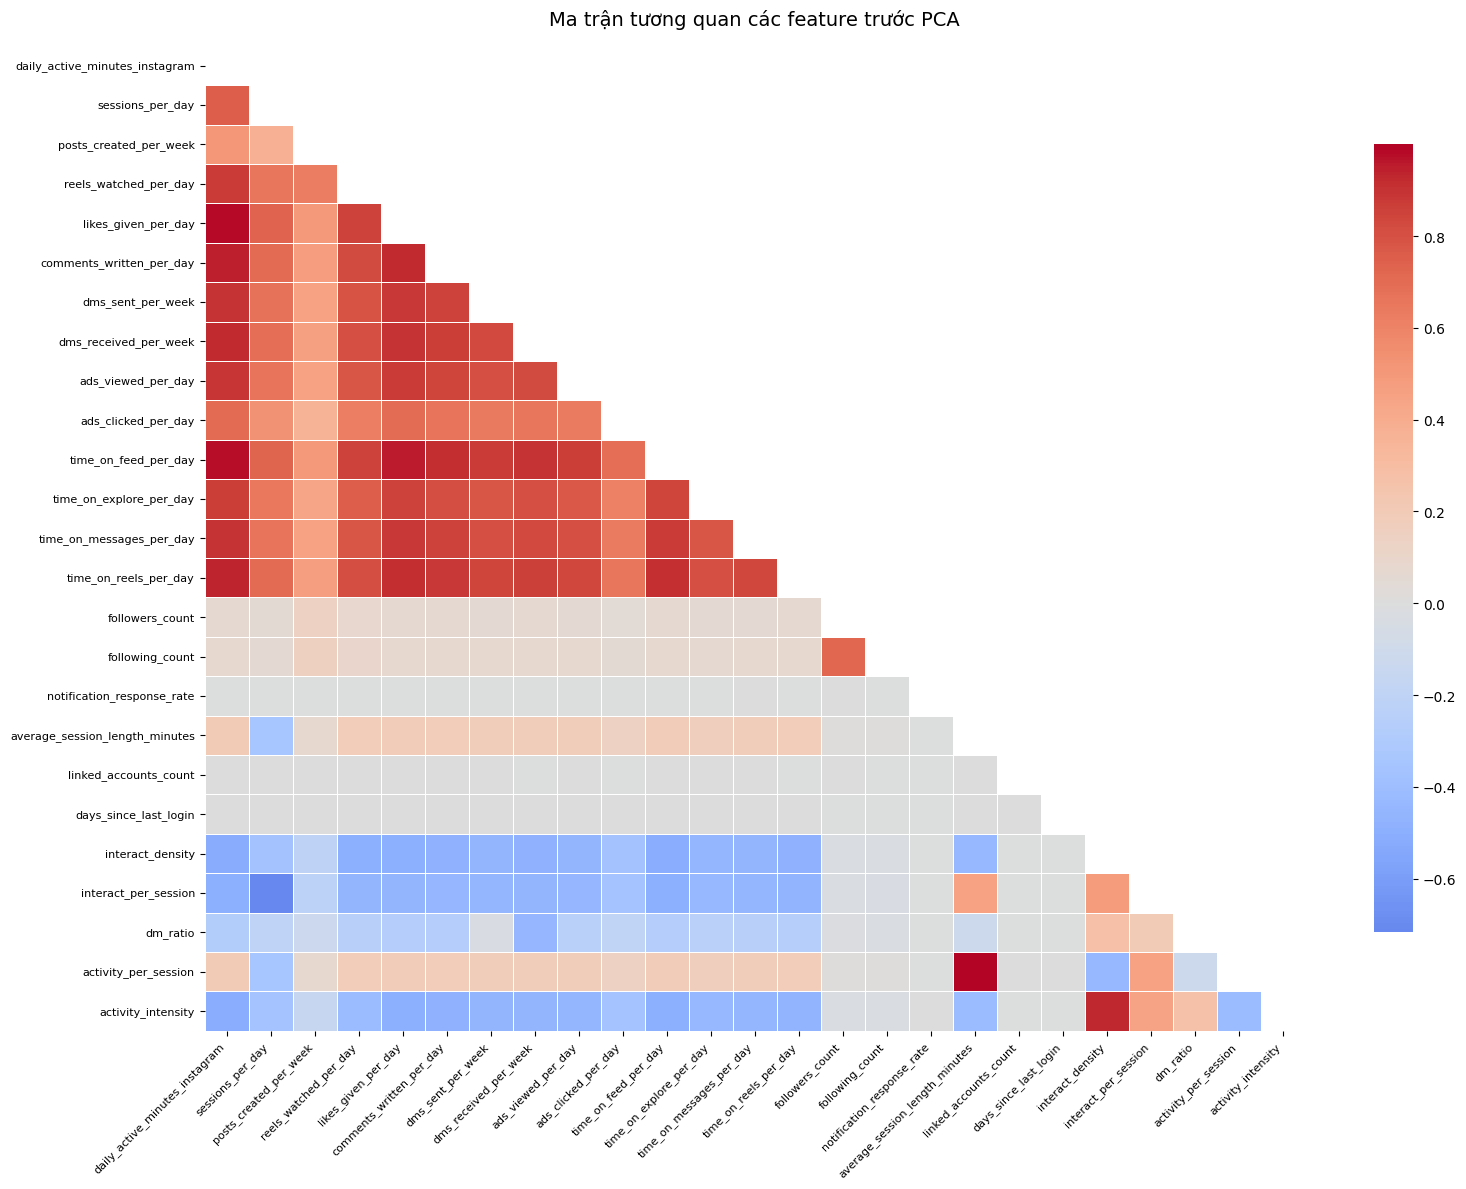

In [33]:
#Vẽ heatmap tương quan để hiểu cấu trúc dữ liệu trước PCA
plt.figure(figsize=(16, 12))
corr_matrix = pd.DataFrame(X_scaled, columns=df_scale.columns).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ hiện nửa dưới
sns.heatmap(
    corr_matrix, mask=mask, annot=False, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Ma trận tương quan các feature trước PCA', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
#Lọc thuộc tính bằng PCA
pca = PCA(n_components=0.9)#Giữ lại 90% thông tin
X_pca = pca.fit_transform(X_scaled)
print("Shape sau PCA:", X_pca.shape)

Shape sau PCA: (499999, 9)


Explained Variance Ratio từng PC:
  PC 1:  48.10%  |  Cumulative:  48.10%
  PC 2:  11.00%  |  Cumulative:  59.10%
  PC 3:   6.98%  |  Cumulative:  66.08%
  PC 4:   5.81%  |  Cumulative:  71.89%
  PC 5:   4.01%  |  Cumulative:  75.89%
  PC 6:   4.00%  |  Cumulative:  79.89%
  PC 7:   3.99%  |  Cumulative:  83.89%
  PC 8:   3.86%  |  Cumulative:  87.75%
  PC 9:   2.90%  |  Cumulative:  90.65%


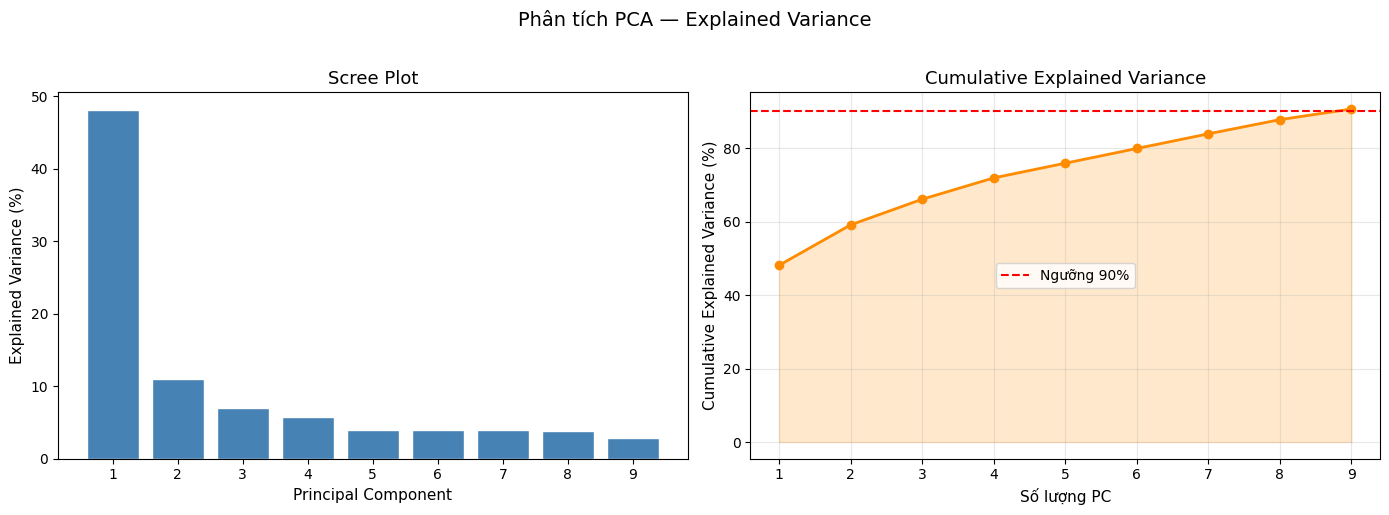

In [35]:
# In chi tiết explained variance từng PC
print("Explained Variance Ratio từng PC:")
cumsum = 0
for i, ratio in enumerate(pca.explained_variance_ratio_):
    cumsum += ratio
    print(f"  PC{i+1:2d}: {ratio*100:6.2f}%  |  Cumulative: {cumsum*100:6.2f}%")

# Biểu đồ Scree Plot + Cumulative Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('Scree Plot', fontsize=13)
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Cumulative Explained Variance
cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='darkorange', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', label='Ngưỡng 90%')
axes[1].fill_between(range(1, len(cumulative) + 1), cumulative, alpha=0.2, color='darkorange')
axes[1].set_xlabel('Số lượng PC', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].set_xticks(range(1, len(cumulative) + 1))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Phân tích PCA — Explained Variance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Top 5 feature đóng góp DƯƠNG nhất vào từng PC:

  PC1:
    daily_active_minutes_instagram           +0.2844
    likes_given_per_day                      +0.2792
    time_on_feed_per_day                     +0.2784
    comments_written_per_day                 +0.2701
    time_on_reels_per_day                    +0.2686

  PC2:
    activity_per_session                     +0.5841
    average_session_length_minutes           +0.5841
    interact_per_session                     +0.3286
    sessions_per_day                         -0.3080
    interact_density                         -0.2334

  PC3:
    following_count                          +0.6795
    followers_count                          +0.6783
    posts_created_per_week                   +0.1724
    activity_intensity                       +0.1233
    interact_density                         +0.1129

  PC4:
    activity_intensity                       +0.5195
    interact_density                         +0.5160
    interact_per_ses

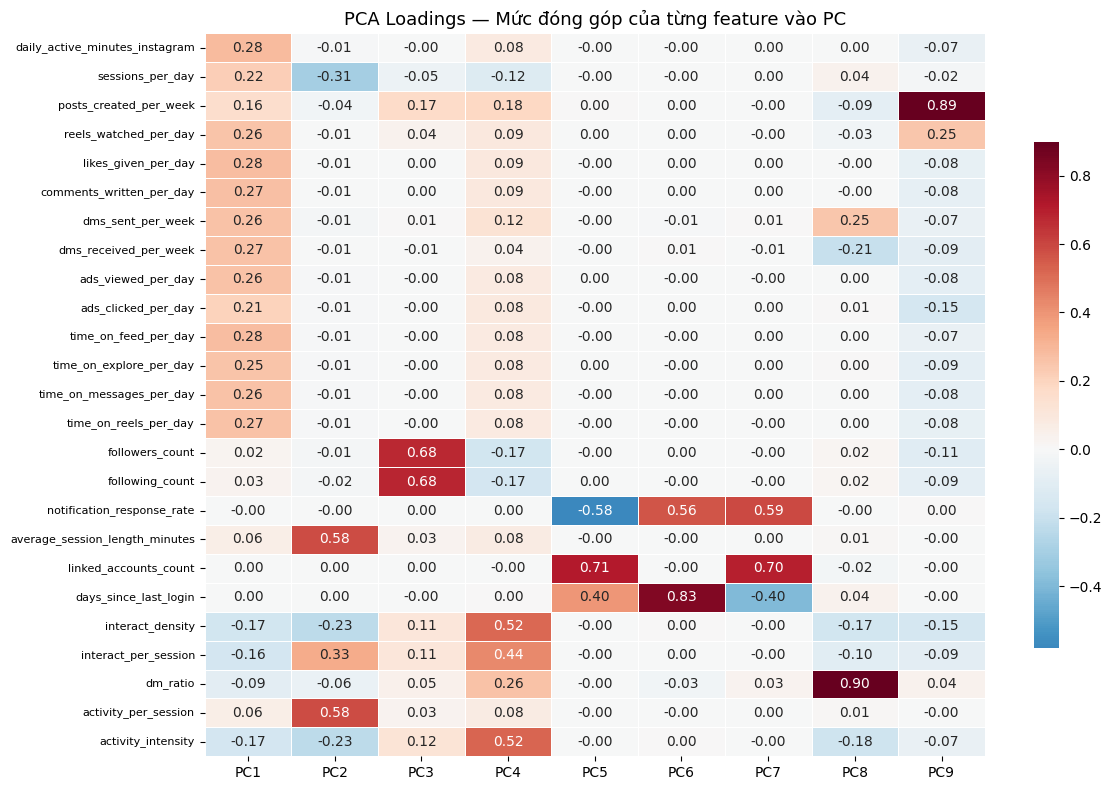

In [36]:
# Hiển thị top feature đóng góp vào từng PC
# Giúp ta đặt tên ý nghĩa cho từng PC (vd: PC1 = 'mức độ xem nội dung', PC2 = 'mức độ tương tác',...)
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_scale.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Top 5 feature đóng góp nhiều nhất vào từng PC:")
for pc in loadings.columns:
    top5 = loadings[pc].abs().nlargest(5)
    print(f"\n  {pc}:")
    for feat in top5.index:
        val = loadings.loc[feat, pc]
        print(f"    {feat:<40s} {val:+.4f}")

# Heatmap loadings
plt.figure(figsize=(12, 8))
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.4, cbar_kws={'shrink': 0.7}
)
plt.title('PCA Loadings — Mức đóng góp của từng feature vào PC', fontsize=13)
plt.xticks(rotation=0)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

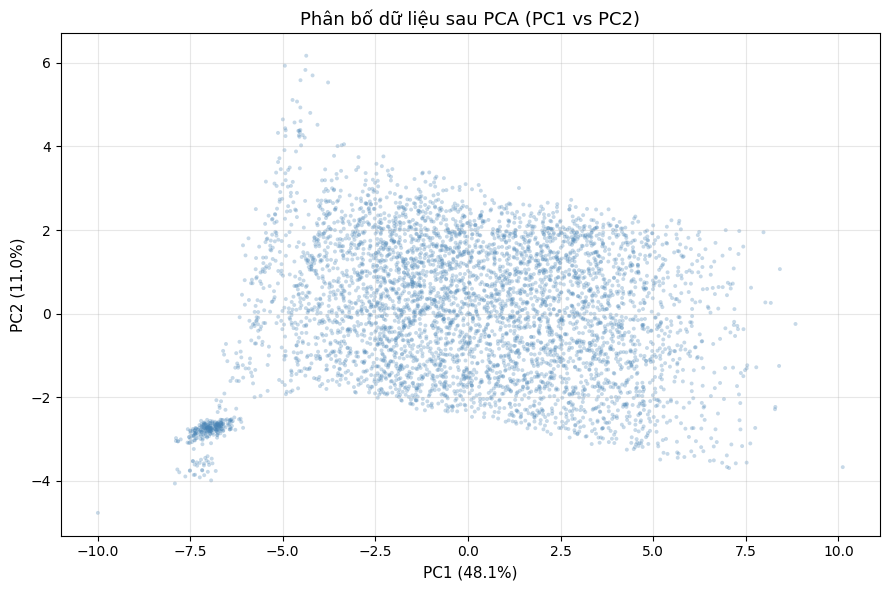

In [37]:
# Scatter plot PC1 vs PC2 — kiểm tra cấu trúc cụm trực quan
# Sample 5000 điểm để vẽ nhanh
idx_plot = np.random.choice(len(X_pca), size=min(5000, len(X_pca)), replace=False)

plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[idx_plot, 0], X_pca[idx_plot, 1],
    alpha=0.3, s=8, c='steelblue', edgecolors='none'
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
plt.title('Phân bố dữ liệu sau PCA (PC1 vs PC2)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
X_pca_df = pd.DataFrame(X_pca,columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

In [ ]:
X_pca_df.to_csv("/content/drive/MyDrive/KhaiPhaDuLieu/dataset_final.csv", index=False)